# VIII. shipments.csv — Vận chuyển


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

shipments_df['shipping_fee'] = pd.to_numeric(shipments_df['shipping_fee'], errors='coerce')
shipments_df['shipping_lead_time_days'] = (shipments_df['delivery_date'] - shipments_df['ship_date']).dt.days

weekday_map = {
    'Monday': 'Thứ 2',
    'Tuesday': 'Thứ 3',
    'Wednesday': 'Thứ 4',
    'Thursday': 'Thứ 5',
    'Friday': 'Thứ 6',
    'Saturday': 'Thứ 7',
    'Sunday': 'Chủ nhật'
}
shipments_df['ship_weekday'] = shipments_df['ship_date'].dt.day_name().map(weekday_map)

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [2]:
shipments_df.head(10)

,order_id,ship_date,delivery_date,shipping_fee,shipping_lead_time_days,ship_weekday
0,1,2012-07-07,2012-07-11,1.37,4,Thứ 7
1,2,2012-07-06,2012-07-10,2.60,4,Thứ 6
2,3,2012-07-04,2012-07-07,2.38,3,Thứ 4
3,4,2012-07-05,2012-07-11,2.49,6,Thứ 5
4,6,2012-07-09,2012-07-16,25.79,7,Thứ 2
5,7,2012-07-06,2012-07-12,1.31,6,Thứ 6
6,8,2012-07-06,2012-07-11,0.43,5,Thứ 6
7,9,2012-07-07,2012-07-13,0.18,6,Thứ 7
8,10,2012-07-07,2012-07-13,0.86,6,Thứ 7
9,13,2012-07-09,2012-07-12,2.44,3,Thứ 2


In [3]:
shipments_df.shape

(566067, 6)

In [4]:
shipments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 566067 non-null  int64         
 1   ship_date                566067 non-null  datetime64[us]
 2   delivery_date            566067 non-null  datetime64[us]
 3   shipping_fee             566067 non-null  float64       
 4   shipping_lead_time_days  566067 non-null  int64         
 5   ship_weekday             566067 non-null  str           
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 25.9 MB


In [5]:
shipments_df.columns

Index(['order_id', 'ship_date', 'delivery_date', 'shipping_fee',
       'shipping_lead_time_days', 'ship_weekday'],
      dtype='str')

In [6]:
overview_df = pd.DataFrame({
    'missing_count': shipments_df.isna().sum(),
    'missing_rate_%': (shipments_df.isna().mean() * 100).round(2),
    'n_unique': shipments_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
order_id,0,0.00,566067
ship_date,0,0.00,3831
delivery_date,0,0.00,3831
shipping_fee,0,0.00,1856
shipping_lead_time_days,0,0.00,6
ship_weekday,0,0.00,7


In [7]:
date_summary_df = pd.DataFrame({
    'ship_date_min': [shipments_df['ship_date'].min()],
    'ship_date_max': [shipments_df['ship_date'].max()],
    'delivery_date_min': [shipments_df['delivery_date'].min()],
    'delivery_date_max': [shipments_df['delivery_date'].max()],
    'free_shipping_count': [(shipments_df['shipping_fee'] == 0).sum()],
    'free_shipping_rate_%': [round((shipments_df['shipping_fee'] == 0).mean() * 100, 2)]
})
date_summary_df

,ship_date_min,ship_date_max,delivery_date_min,delivery_date_max,free_shipping_count,free_shipping_rate_%
0,2012-07-04,2022-12-29,2012-07-06,2022-12-31,805,0.14


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Phân phối và outlier


Da luu bieu do ket hop tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/shipments_distribution_boxplot.png


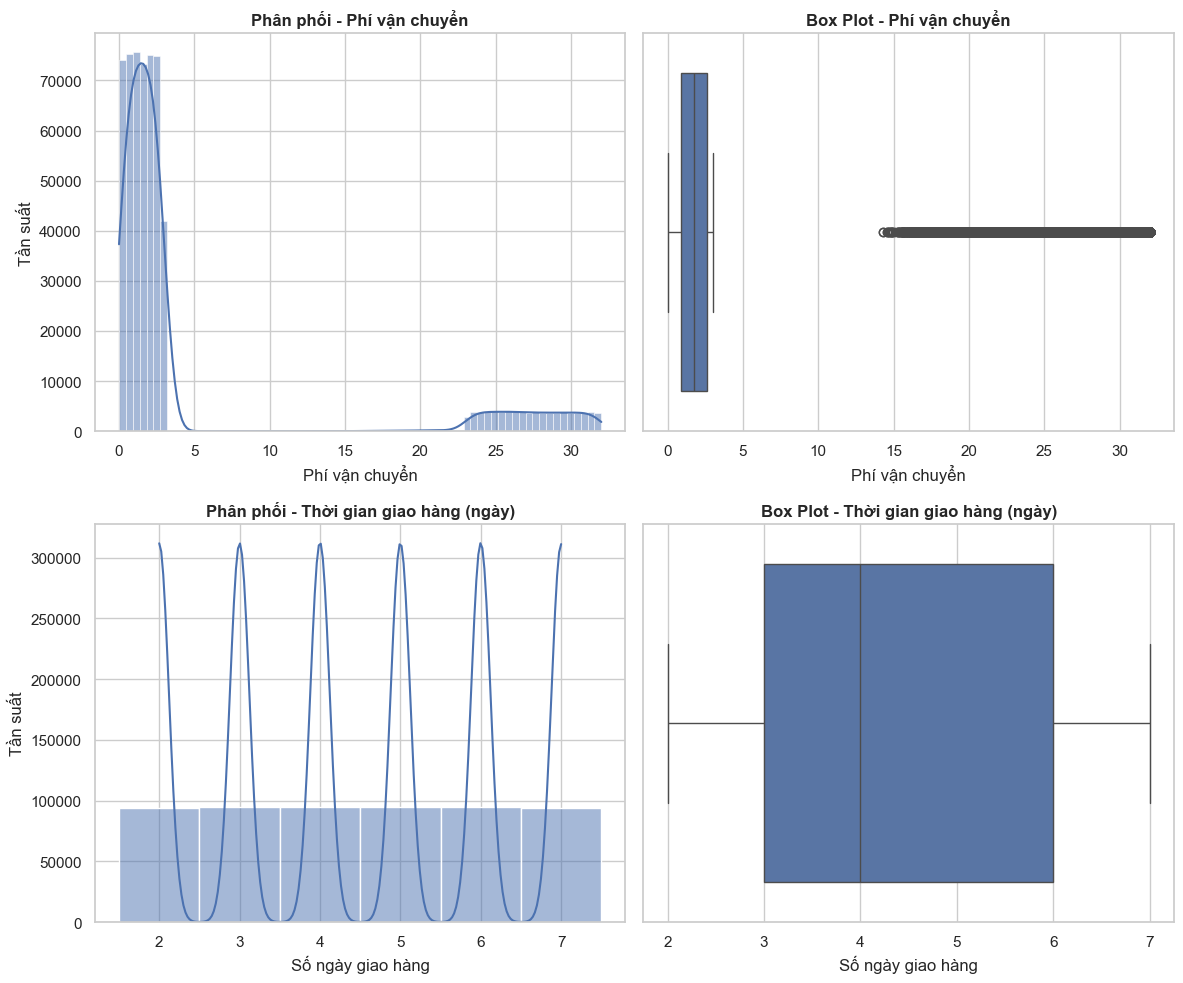

In [8]:
col_config = {
    'shipping_fee': {
        'title': 'Phí vận chuyển',
        'xlabel': 'Phí vận chuyển',
        'hist_kwargs': {'bins': 70}
    },
    'shipping_lead_time_days': {
        'title': 'Thời gian giao hàng (ngày)',
        'xlabel': 'Số ngày giao hàng',
        'hist_kwargs': {'discrete': True}
    }
}

con_cols_names = ['shipping_fee', 'shipping_lead_time_days']

def format_axis(ax, col_name, values):
    if col_name == 'shipping_lead_time_days':
        ax.set_xticks(sorted(values.unique()))

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

plot_distribution_boxplot(
    shipments_df,
    con_cols_names,
    save_path=os.path.join(IMAGES_DIR, 'shipments_distribution_boxplot.png')
)

#### b. Thống kê mô tả


In [9]:
shipments_df[['shipping_fee', 'shipping_lead_time_days']]\
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,shipping_fee,shipping_lead_time_days
count,566067.00,566067.00
mean,4.96,4.50
std,8.89,1.71
min,0.00,2.00
1%,0.04,2.00
5%,0.17,2.00
25%,0.87,3.00
50%,1.73,4.00
75%,2.60,6.00
90%,25.09,7.00


In [10]:
q1 = shipments_df['shipping_fee'].quantile(0.25)
q3 = shipments_df['shipping_fee'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (shipments_df['shipping_fee'] < lower_bound) | (shipments_df['shipping_fee'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(shipments_df) * 100

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'So luong outlier (IQR): {outlier_count:,}')
print(f'Ty le outlier (IQR): {outlier_rate:.2f}%')

Q1: 0.87
Q3: 2.60
IQR: 1.73
Lower bound: -1.72
Upper bound: 5.20
So luong outlier (IQR): 76,050
Ty le outlier (IQR): 13.43%


**Nhận xét:**

- **Quan sát:**
  - Phí vận chuyển (`shipping_fee`): Phân bố lệch phải (right-skewed) cực tím. Mật độ tập trung ở 0 hoặc rất nhỏ, kèm lượng lớn outliers kéo dài về đuôi phải.
  - Thời gian giao hàng (`shipping_lead_time_days`): Biến số nguyên rời rạc, tập trung ở các mốc 2, 3, 4 ngày. Đuôi dài thể hiện một bộ phận đơn hàng bị giao lâu hơn bình thường.

- **Insights:**
  - Về Phí vận chuyển: Chính sách "Miễn phí" hoặc phí thấp đóng vai trò chủ đạo. Các giá trị ngoại lai cước phí cao có thể phát sinh do giao hàng khác khu vực, địa lý vùng sâu xa, hoặc do đơn ghép nhiều kiện.
  - Về Lead Time: Hệ thống có mô hình vận hành khá ổn định trong ngắn ngày. Đuôi dài phản ánh lượng đơn có thể gặp sự cố tồn đọng kho bãi hoặc địa lý xa. 

- **Gợi ý hành động:**
  - Check chéo với Không gian địa lý: Kiểm tra bảng thông tin khu vực nhận (`geography.csv`) để xác nhận trực tiếp giả thuyết phí cao từ khoảng cách hành chính.
  - SLA Monitoring: Nhóm các đơn `lead_time` vượt mức thông thường (vd: > 7 ngày) đối chiếu với tỷ lệ trả hàng / đánh giá 1-sao ở `returns.csv` và `reviews.csv` để đo lường mức độ thiệt hại trải nghiệm.

### 1.1.2. Biến phân loại (Categorical)


Da luu bieu do categorical tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/shipments_categorical_distribution.png


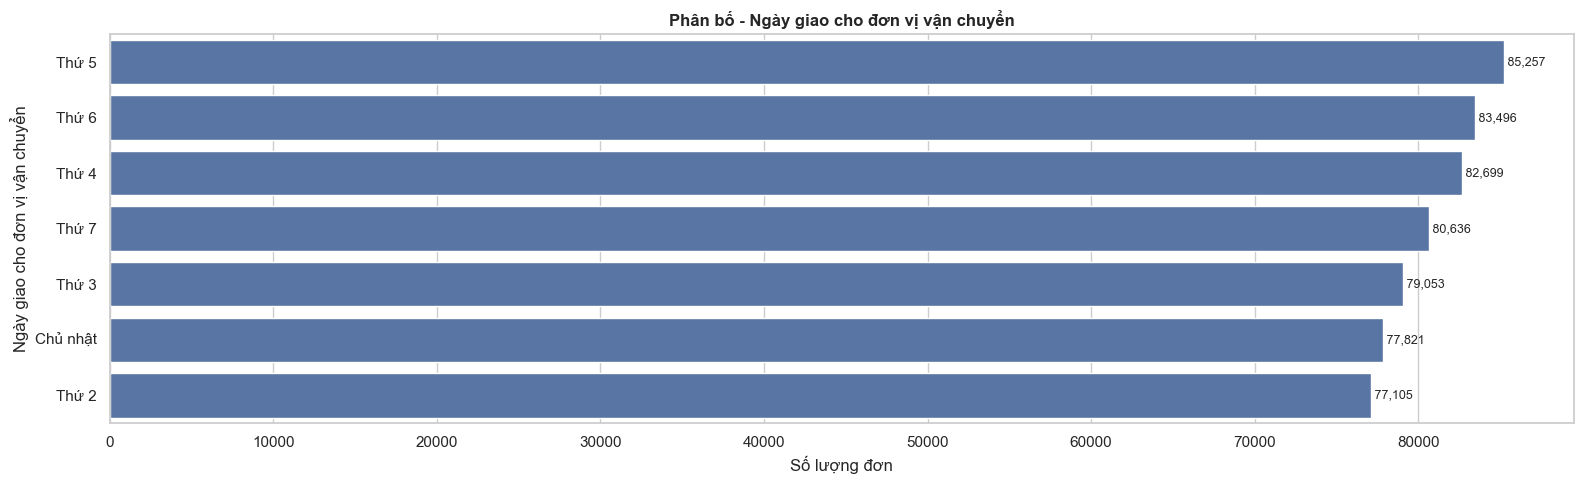

In [11]:
COL_INFO = {
    'ship_weekday': {'name': 'Ngày giao cho đơn vị vận chuyển', 'unit': 'đơn'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)
    
    # Handling case where there is only 1 categorical column
    if cols > n:
        cols = n
    if rows == 0:
        rows = 1

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    # reshape(-1) works if size > 1, otherwise just make it a list
    if not isinstance(axes, (np.ndarray, list)):
        axes = [axes]
    else:
        axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    shipments_df,
    ['ship_weekday'],
    save_path=os.path.join(IMAGES_DIR, 'shipments_categorical_distribution.png')
)

In [12]:
weekday_stats = shipments_df['ship_weekday'].value_counts(dropna=False).to_frame(name='count')
weekday_stats['rate_%'] = (weekday_stats['count'] / len(shipments_df) * 100).round(2)
weekday_stats

,count,rate_%
ship_weekday,,
Thứ 5,85257,15.06
Thứ 6,83496,14.75
Thứ 4,82699,14.61
Thứ 7,80636,14.24
Thứ 3,79053,13.97
Chủ nhật,77821,13.75
Thứ 2,77105,13.62


**Nhận xét:**

- **Quan sát:**
  - Ngày giao hàng (`ship_weekday`): Khối lượng đơn xuất kho khá đồng đều trong các ngày làm việc (thứ 2 đến thứ 6), tuy nhiên lại sụt giảm đáng kể vào cuối tuần (Thứ 7 và Chủ nhật).

- **Insights:**
  - Nhịp điệu vận hành (Rhythm of operations): Hoạt động xử lý đơn hàng/bàn giao vận chuyển đang có tính chu kỳ tuần rõ nét. Mức hoạt động chùng xuống theo lịch nghỉ ngơi cuối tuần. Do đơn hàng được đặt dàn trải nhưng dồn ứ lại vào cuối tuần, nó sẽ tạo thành đợt tích tụ và được kho xử lý ồ ạt vào Thứ 2.

- **Gợi ý hành động:**
  - Tối ưu nhân sự kho bãi: Cân nhắc mức độ ách tắc (bottleneck) đầu tuần để đánh giá năng suất xuất kho, điều chỉnh ca trực kho bãi vào thời điểm trống.

### 1.1.3. Biến thời gian


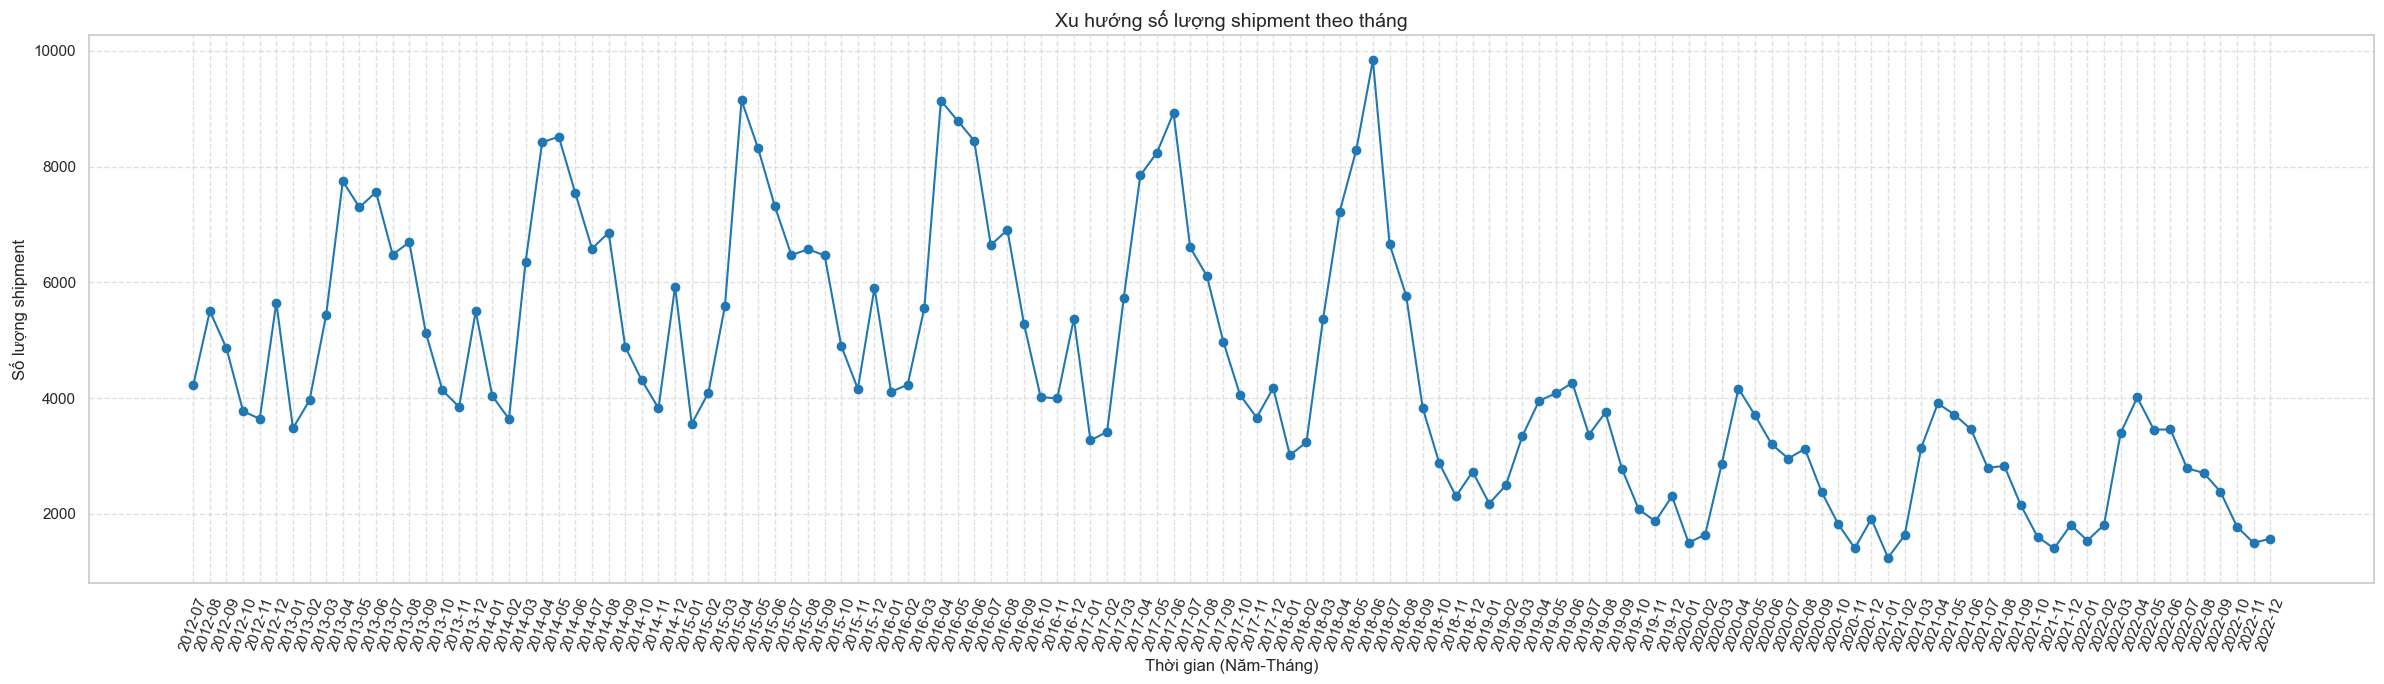

In [13]:
shipments_df['year_month'] = shipments_df['ship_date'].dt.to_period('M')

monthly_shipments = shipments_df.groupby('year_month').size().reset_index(name='shipment_count')
monthly_shipments['year_month'] = monthly_shipments['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_shipments['year_month'], monthly_shipments['shipment_count'], color='tab:blue', marker='o', linestyle='-')
ax.set_title('Xu hướng số lượng shipment theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Số lượng shipment')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

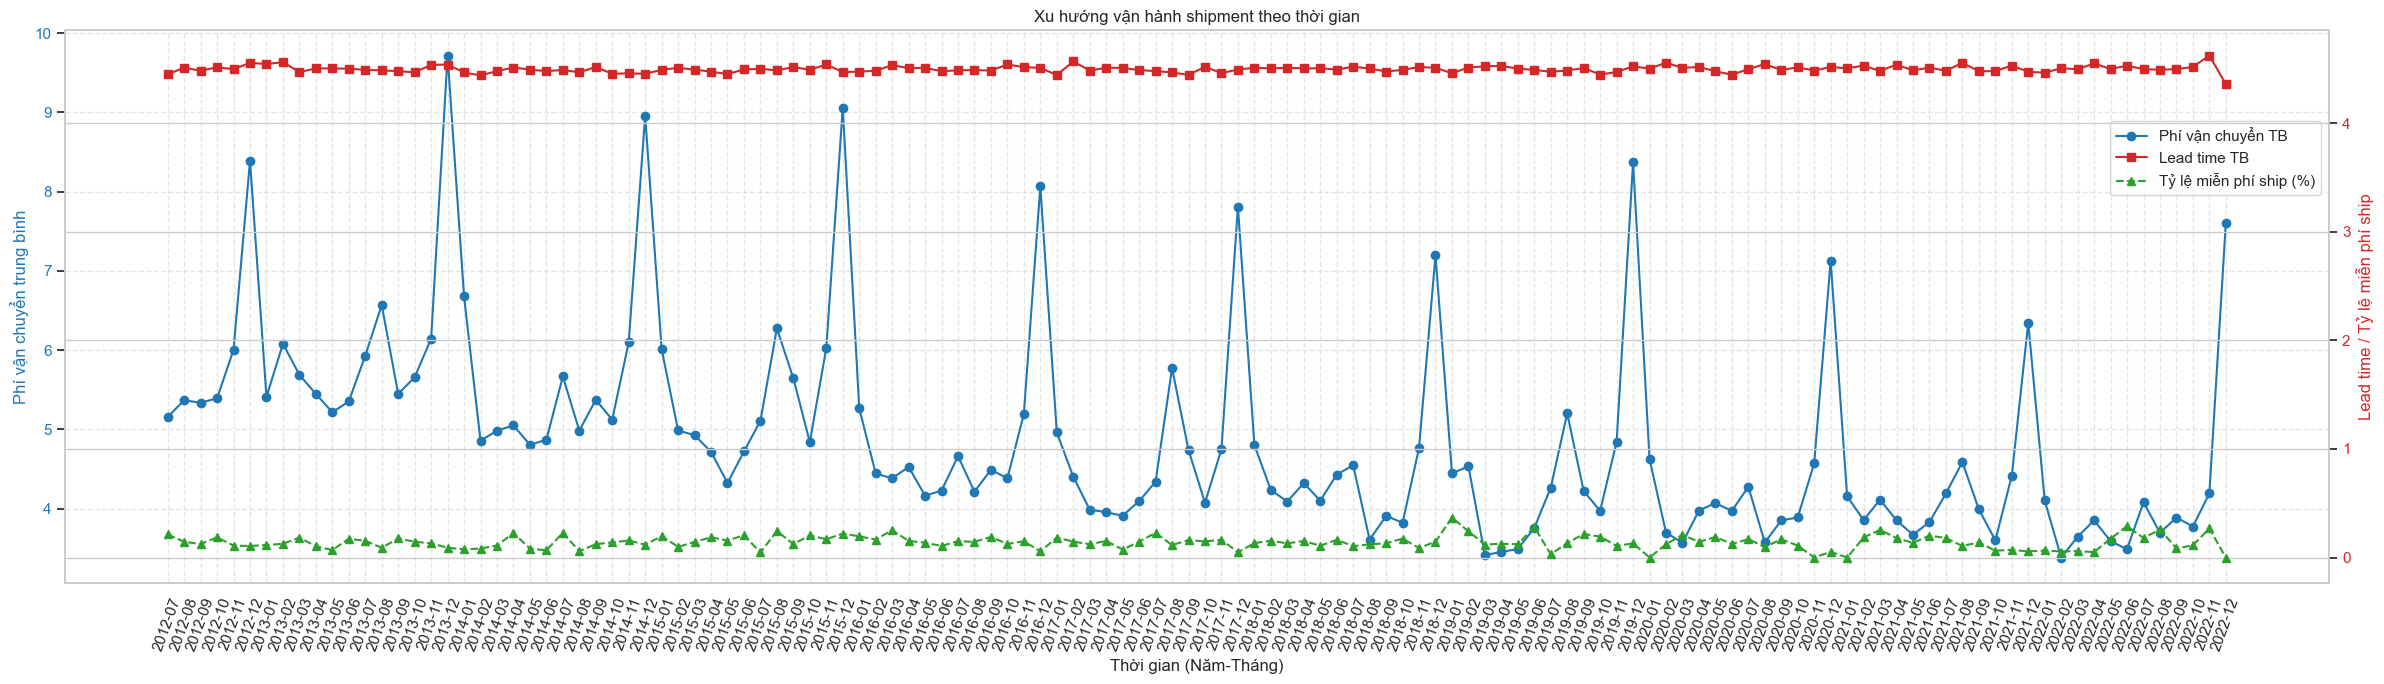

In [14]:
monthly_operational = shipments_df.groupby('year_month').agg(
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_lead_time_days=('shipping_lead_time_days', 'mean'),
    free_shipping_rate=('shipping_fee', lambda x: (x == 0).mean() * 100)
).reset_index()
monthly_operational['year_month'] = monthly_operational['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(24, 7))

ax1.plot(monthly_operational['year_month'], monthly_operational['avg_shipping_fee'], color='tab:blue', marker='o', label='Phí vận chuyển TB')
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Phí vận chuyển trung bình', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_operational['year_month'], monthly_operational['avg_lead_time_days'], color='tab:red', marker='s', label='Lead time TB')
ax2.plot(monthly_operational['year_month'], monthly_operational['free_shipping_rate'], color='tab:green', marker='^', linestyle='--', label='Tỷ lệ miễn phí ship (%)')
ax2.set_ylabel('Lead time / Tỷ lệ miễn phí ship', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', bbox_to_anchor=(1, 0.85))
plt.title('Xu hướng vận hành shipment theo thời gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Xu hướng số lượng đơn hàng biến thiên liên tục theo từng tháng, có biểu hiện mùa vụ với những đỉnh chóp (peaks) rõ ràng (có thể trùng vào dịp chiến dịch/Sales).
  - Biều đồ biến động vận hành: Khi tỷ lệ "Miễn phí vận chuyển" tăng cao tại các đỉnh xả hàng, "Lead time trung bình" (thời gian giao hàng) cũng thường có xu hướng biến động, trong khi Phí trung bình giảm xuống.

- **Insights:**
  - Khuyến mãi kích cầu hiệu quả: Sự gia tăng đột biến của Freeship trùng khớp với sự bùng nổ khối lượng đơn hàng (Volume peak).
  - Đánh đổi vận hành (Operation Trade-off): Các peak volumn kéo theo hiệu ứng phụ là quá tải năng lực xử lý (capacity overload) của đối tác vận chuyển hoặc kho bãi, dẫn đến tình trạng kéo dài Lead Time.

- **Gợi ý hành động:**
  - Kế hoạch Capacity Planning: Dự báo Time-series trên dữ liệu giao hàng để ước tính Peak Load trước các kỳ có chương trình promotion (`promotions.csv`), dự trù tăng thiết bị/nhân sự xử lý hóa đơn, phân phối lại băng thông.
  - Phân tích cân bằng sự hài lòng: Kiếm tra tỷ lệ đánh giá thấp (`reviews.csv`) ở đúng các tháng có Lead Time căng thẳng để đánh giá mức độ suy giảm trải nghiệm do giao lâu kéo lại tỷ lệ trung tình cảm ứng của người mua.

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [15]:
num_cols = ['shipping_fee', 'shipping_lead_time_days']
corr_df = shipments_df[num_cols].corr()
corr_df

,shipping_fee,shipping_lead_time_days
shipping_fee,1.00,-0.00
shipping_lead_time_days,-0.00,1.00


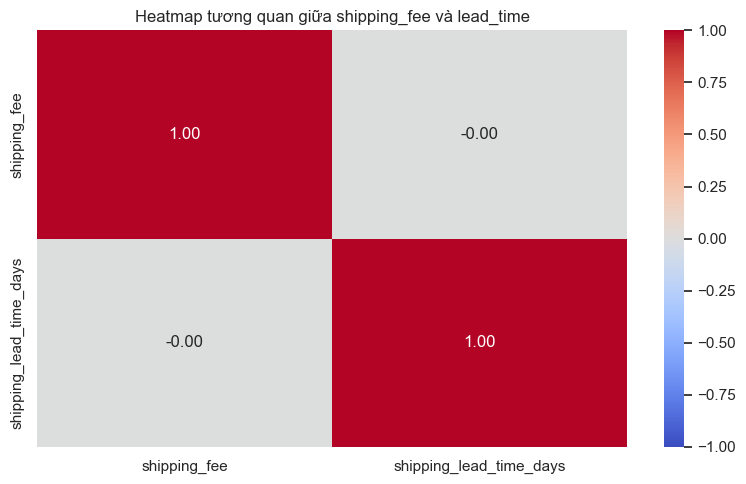

In [16]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa shipping_fee và lead_time')
plt.tight_layout()
plt.show()

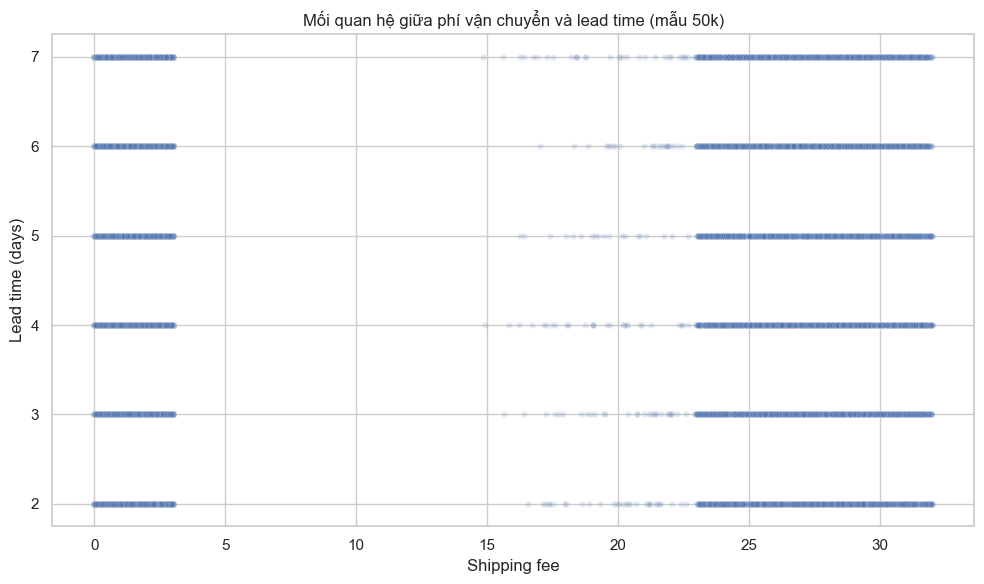

In [17]:
sample_scatter = shipments_df.sample(n=min(50000, len(shipments_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='shipping_fee',
    y='shipping_lead_time_days',
    alpha=0.15,
    s=20
)
plt.title('Mối quan hệ giữa phí vận chuyển và lead time (mẫu 50k)')
plt.xlabel('Shipping fee')
plt.ylabel('Lead time (days)')
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Hệ số tương quan (Heatmap) giữa `shipping_fee` và `shipping_lead_time_days` gần như bằng 0 (không có quan hệ tuyến tính).
  - Đồ thị Scatter plot thể hiện rõ: Việc khách hàng trả cước vận chuyển cao KHÔNG đồng nghĩa họ nhận được hàng hóa trong số ngày ngắn hơn. Nhóm được Miễn phí ship vẫn nhận hàng nhanh tương đương với nhóm bị thu cước cao.

- **Insights:**
  - Khoảng cách chi phí không quyết định vận tốc: Phí vận chuyển phụ thuộc vào yếu tố địa lý vùng nhận hàng (`geography.csv`) thay vì mức độ ưu tiên thời gian trả phí giao tốc hành.
  - Phổ cập dịch vụ tiêu chuẩn: Toàn bộ hệ thống hầu như bám theo mức dịch vụ Standard đơn giản với tốc độ giao hàng như nhau phụ thuộc vào lộ trình tuyến đường/nguyên tắc kho vùng.

- **Gợi ý hành động:**
  - Tái cơ cấu Options (Delivery Tiers): Cần đánh giá tiềm năng xây dựng các gói giao nhanh / giao tiết kiệm. Việc phí cao nhưng lead time vẫn như cũ dễ dẫn đến bức xúc do khách hàng lầm tưởng họ đang phải chịu tiền giao siêu tốc.

### **Câu hỏi: Sự thay đổi trong hành vi và xu hướng thanh toán qua các tháng tác động như thế nào đến tổng doanh thu của hệ thống?**

#### Câu hỏi nhỏ 1: Tỷ trọng của các phương thức thanh toán trả trước (Credit Card, Paypal, Apple Pay) so với trả sau (COD) có sự dịch chuyển ra sao trong những tháng đạt đỉnh (peak) doanh thu?

#### Câu hỏi nhỏ 2: Việc ưu đãi hoặc mở rộng các lựa chọn trả góp (installments) ở kỳ hạn dài (6-12 tháng) có thực sự thúc đẩy sự gia tăng của Giá trị đơn hàng trung bình (AOV) theo thời gian hay không?

#### Câu hỏi nhỏ 3: Tỷ lệ giao dịch lỗi, từ chối thanh toán hoặc hủy đơn có xu hướng tăng đột biến vào các chu kỳ có volume thanh toán tăng mạnh (như mùa lễ hội/Mega Sale) gây rò rỉ doanh thu không?